In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
url = "https://raw.githubusercontent.com/nunnarilabs/ml/master/house/kc_house_data.csv"
df = pd.read_csv(url)

print(df.head())
print(df.info())

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0      5650     1.0           0     0  ...      7        1180              0   
1      7242     2.0           0     0  ...      7        2170            400   
2     10000     1.0           0     0  ...      6         770              0   
3      5000     1.0           0     0  ...      7        1050            910   
4      8080     1.0           0     0  ...      8        1680              0   

   yr_built  yr_renovated  zipcode      lat     lo

In [3]:
f = df.drop(['id', 'date'], axis=1)

# Check null values
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [4]:
y = df['price']

In [5]:
X_simple = df[['sqft_living']]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

In [6]:
print("\n--- Simple Linear Regression ---")
print("MSE:", mean_squared_error(y_test_s, y_pred_s))
print("MAE:", mean_absolute_error(y_test_s, y_pred_s))
print("R2 Score:", r2_score(y_test_s, y_pred_s))


--- Simple Linear Regression ---
MSE: 76484977061.77612
MAE: 177867.54034434858
R2 Score: 0.49406905389089006


In [8]:
X_multi = df.drop(['price', 'date'], axis=1, errors='ignore')


In [9]:
X_multi = X_multi.select_dtypes(include=[np.number])

In [10]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

In [11]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)


LinearRegression()

In [12]:
y_pred_m = model_multi.predict(X_test_m)


In [13]:
print("\n--- Multiple Linear Regression ---")
print("MSE:", mean_squared_error(y_test_m, y_pred_m))
print("MAE:", mean_absolute_error(y_test_m, y_pred_m))
print("R2 Score:", r2_score(y_test_m, y_pred_m))


--- Multiple Linear Regression ---
MSE: 45164817780.90123
MAE: 127474.10296304949
R2 Score: 0.7012448735876462


In [14]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_simple)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

model_poly = LinearRegression()
model_poly.fit(X_train_p, y_train_p)

y_pred_p = model_poly.predict(X_test_p)

In [15]:
print("\n--- Polynomial Regression (Degree 2) ---")
print("MSE:", mean_squared_error(y_test_p, y_pred_p))
print("MAE:", mean_absolute_error(y_test_p, y_pred_p))
print("R2 Score:", r2_score(y_test_p, y_pred_p))



--- Polynomial Regression (Degree 2) ---
MSE: 82113931183.64449
MAE: 171786.30972476854
R2 Score: 0.45683478653690435


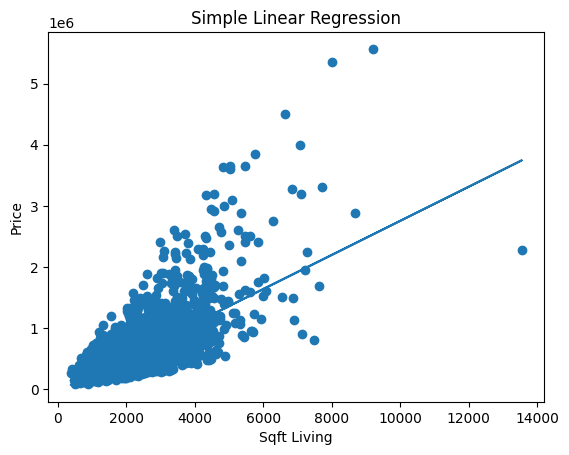

In [16]:
plt.figure()
plt.scatter(X_test_s, y_test_s)
plt.plot(X_test_s, y_pred_s)
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.show()